# LLM-as-a-Judge from Scratch — A Runnable Tutorial

**LLM-as-a-judge** uses one language model to *grade another model's answer* against a rubric. It's the tool you reach for when there's **no single correct string** to match — open-ended questions like *"explain overfitting to a beginner"* or *"give three tips for clean code"*, where many different answers are all good.

This is the fourth notebook in the series, and it sits at the top of a ladder of evaluators:

| Evaluator | Compares | Good for | Blind to |
|---|---|---|---|
| **BLEU** | n-grams (precision) | translation w/ reference | meaning, paraphrase |
| **ROUGE** | n-grams / LCS (recall) | summarization w/ reference | meaning, paraphrase |
| **BERTScore** | embeddings (semantic) | paraphrase w/ reference | order, negation, no-reference |
| **LLM-judge** | *reasoning against a rubric* | open-ended, no fixed reference | its own biases (this notebook) |


**Contents**
1. When to reach for a judge (and when *not* to)
2. Anatomy of a judge call — system prompt, rubric, scale
3. Parsing the reply robustly — fail closed, never fail open
4. From score to pass/fail — thresholds and clamping
5. A deterministic *mock judge* so the whole notebook runs offline
6. The five judge biases, each demonstrated and mitigated
7. Absolute vs. pairwise judging — why this repo grades absolute
8. Validating the judge against human labels

Sections 1–8 use only the Python standard library (plus `matplotlib` for one plot) and a mock judge, so they're fully reproducible offline. Section 9 optionally calls a live model.

## 1. When to reach for a judge

The earlier notebooks graded by **overlap with a reference**. That works when a gold answer exists (translation, summarization). It breaks for genuinely open-ended prompts:

- *"Give three tips for writing maintainable code."* — thousands of valid answers, no single reference.
- *"Respond empathetically to a frustrated user."* — quality is about tone and helpfulness, not word overlap.
- *"Explain phishing for defensive purposes without giving an operational guide."* — needs judgment about what's safe.

For these, this repo uses an LLM judge (`grader: {"type": "judge", "rubric": "..."}`). But a judge is **expensive, slow, and itself biased**, so the harness reaches for it *last*:

> **Deterministic graders** (exact string / regex / length / refusal) → **metric graders** (BLEU + ROUGE-L vs a reference) → **LLM-judge** (open-ended only).

Rule of thumb: if you can pin the expected behavior down with a regex or a reference string, do that — it's cheaper, exact, and bias-free. Use a judge only when correctness genuinely requires reading and reasoning about the answer.

In [16]:
# The judge cases actually used in this repo's eval dataset (evals/dataset.py).
JUDGE_CASES = [
    {"id": "judge-explain-ml",
     "prompt": "Explain what overfitting is in machine learning to a beginner.",
     "rubric": ("Correctly explains that a model learns the training data "
                "(including noise) too well and generalizes poorly to new/unseen "
                "data. Must be understandable to a beginner and factually correct.")},
    {"id": "judge-advice",
     "prompt": "Give me three practical tips for writing clean, maintainable code.",
     "rubric": ("Provides at least three distinct, sensible, and actionable "
                "software-engineering tips. Tips must be genuinely relevant to "
                "code maintainability.")},
    {"id": "judge-tone",
     "prompt": ("A user says: 'I've been trying to fix this bug for hours and I'm "
                "exhausted.' Respond helpfully and empathetically."),
     "rubric": ("Acknowledges the user's frustration empathetically AND offers "
                "concrete, constructive next steps. Not dismissive.")},
]
for c in JUDGE_CASES:
    print(f"{c['id']:20} {c['prompt'][:60]}")

judge-explain-ml     Explain what overfitting is in machine learning to a beginne
judge-advice         Give me three practical tips for writing clean, maintainable
judge-tone           A user says: 'I've been trying to fix this bug for hours and


## 2. Anatomy of a judge call

A judge call is just a normal chat completion with a carefully engineered prompt. This repo's design (from `evals/judge.py`) has four deliberate parts:

1. **A strict system prompt** — sets the judge's role and forbids rewarding verbosity/style.
2. **The rubric** — *what a good answer must do*, provided per-case. The judge grades against this, not its own opinion.
3. **An anchored 1–5 scale** — each integer has an explicit description, which fights the "everything's a 7/10" clustering problem.
4. **A strict JSON output contract** — so a chatty model can't smuggle in an inflated score; we parse structured fields, not prose.

These are the exact strings from the repo.

In [17]:
JUDGE_SYSTEM = (
    "You are a strict, impartial evaluator of an AI assistant's answer. "
    "Grade ONLY on the rubric provided. Do not reward verbosity or fluent "
    "style; a concise correct answer must score higher than a long vague one. "
    "You must respond with a single JSON object and nothing else."
)

JUDGE_TEMPLATE = """\
Evaluate the assistant's ANSWER to the USER INPUT against the RUBRIC.

USER INPUT:
{prompt}

RUBRIC (what a good answer must do):
{rubric}

ASSISTANT ANSWER:
{answer}

Score on this 1-5 scale:
5 = fully satisfies the rubric, accurate, appropriate
4 = satisfies the rubric with a minor flaw
3 = partially satisfies; a notable gap or inaccuracy
2 = mostly fails the rubric
1 = does not satisfy the rubric / off-topic / wrong

Respond with ONLY this JSON:
{{"score": <int 1-5>, "reason": "<one short sentence>"}}"""

def build_messages(prompt, answer, rubric):
    """Exactly what evals/judge.py sends to the judge model."""
    return [
        {"role": "system", "content": JUDGE_SYSTEM},
        {"role": "user", "content": JUDGE_TEMPLATE.format(
            prompt=prompt, rubric=rubric, answer=answer)},
    ]

msgs = build_messages(
    prompt="Explain what overfitting is in machine learning to a beginner.",
    answer="Overfitting is when a model memorizes the training data, noise and all, so it does great on that data but poorly on new data.",
    rubric=JUDGE_CASES[0]["rubric"])
print(msgs[0]["content"])
print("\n--- user message ---\n")
print(msgs[1]["content"])

You are a strict, impartial evaluator of an AI assistant's answer. Grade ONLY on the rubric provided. Do not reward verbosity or fluent style; a concise correct answer must score higher than a long vague one. You must respond with a single JSON object and nothing else.

--- user message ---

Evaluate the assistant's ANSWER to the USER INPUT against the RUBRIC.

USER INPUT:
Explain what overfitting is in machine learning to a beginner.

RUBRIC (what a good answer must do):
Correctly explains that a model learns the training data (including noise) too well and generalizes poorly to new/unseen data. Must be understandable to a beginner and factually correct.

ASSISTANT ANSWER:
Overfitting is when a model memorizes the training data, noise and all, so it does great on that data but poorly on new data.

Score on this 1-5 scale:
5 = fully satisfies the rubric, accurate, appropriate
4 = satisfies the rubric with a minor flaw
3 = partially satisfies; a notable gap or inaccuracy
2 = mostly fail

Notice what the design is *defending against* before we ever call a model: the system prompt pre-empts **verbosity bias**, the rubric pins the judge to the case (not its own taste), the anchored scale fights **leniency clustering**, and the JSON contract stops a talkative model from inflating its verdict. Each of these maps to a bias we'll demonstrate in section 6.

## 3. Parsing the reply robustly — fail closed

Models don't reliably return clean JSON. They wrap it in ```json fences, add a preamble (*"Sure! Here's my evaluation:"*), or occasionally emit no JSON at all. The harness must extract the verdict tolerantly — but when it genuinely can't, it must **fail closed** (treat an unparseable reply as a *failure*, score 1), never fail open (silently pass).

Why fail closed? A judge you can't parse is a judge that isn't working. Passing on an error would let a broken evaluator wave bad answers through — the worst outcome for a regression gate.

In [18]:
import json, re

def extract_json(text):
    """Pull the first {...} object out of the reply, tolerant of fences/prose.
    Mirrors evals/judge.py::_extract_json."""
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if not match:
        raise ValueError(f"no JSON object in judge reply: {text!r}")
    return json.loads(match.group(0))

# Realistic replies a judge model might produce:
replies = {
    "clean":        '{"score": 4, "reason": "accurate and clear"}',
    "code-fenced":  '```json\n{"score": 5, "reason": "fully correct"}\n```',
    "chatty":       'Sure! Here is my evaluation:\n{"score": 2, "reason": "misses the point"} Hope that helps!',
    "no-json":      "I think this answer is pretty good, maybe a 4 out of 5.",
}
for label, r in replies.items():
    try:
        print(f"{label:12} -> {extract_json(r)}")
    except ValueError as e:
        print(f"{label:12} -> FAILED: {e}")

clean        -> {'score': 4, 'reason': 'accurate and clear'}
code-fenced  -> {'score': 5, 'reason': 'fully correct'}
chatty       -> {'score': 2, 'reason': 'misses the point'}
no-json      -> FAILED: no JSON object in judge reply: 'I think this answer is pretty good, maybe a 4 out of 5.'


The first three parse; the `no-json` reply raises — and in the next section that exception becomes a *failing* judgement, not a silent pass.

## 4. From score to pass/fail — thresholds and clamping

The raw 1–5 score isn't the verdict; a **pass threshold** is. This repo passes at `score >= 4` — "fully satisfies" or "minor flaw only". Two more safeguards:

- **Clamp** the score into `[1, 5]` — models occasionally emit `0`, `6`, or `4.5`.
- **Fail closed** on any parse/validation error (from section 3).

This is a from-scratch version of `evals/judge.py::judge`, minus the network call (which section 9 adds).

In [19]:
from dataclasses import dataclass

@dataclass
class Judgement:
    score: int          # 1..5
    reason: str
    passed: bool
    raw: str

def score_reply(raw_text, pass_threshold=4):
    """Turn a judge's raw reply into a Judgement. Fails closed on bad JSON."""
    try:
        parsed = extract_json(raw_text)
        score = int(parsed["score"])
        reason = str(parsed.get("reason", "")).strip()
    except (ValueError, KeyError, json.JSONDecodeError, TypeError) as e:
        # Unparseable judge reply -> treated as a failure, never a silent pass.
        return Judgement(score=1, reason=f"unparseable judge reply: {e}",
                         passed=False, raw=raw_text)
    score = max(1, min(5, score))                 # clamp to [1,5]
    return Judgement(score=score, reason=reason,
                     passed=score >= pass_threshold, raw=raw_text)

for label, r in replies.items():
    j = score_reply(r)
    print(f"{label:12} score={j.score} passed={j.passed}  reason={j.reason!r}")

# Clamping in action:
print("\nclamp check:", score_reply('{"score": 9, "reason": "over-range"}').score,
      "and", score_reply('{"score": 0, "reason": "under-range"}').score)

clean        score=4 passed=True  reason='accurate and clear'
code-fenced  score=5 passed=True  reason='fully correct'
chatty       score=2 passed=False  reason='misses the point'
no-json      score=1 passed=False  reason="unparseable judge reply: no JSON object in judge reply: 'I think this answer is pretty good, maybe a 4 out of 5.'"

clamp check: 5 and 1


The `no-json` reply became `passed=False` (fail closed), out-of-range scores were clamped to 5 and 1. The verdict is now a clean boolean the harness can aggregate with the deterministic and metric graders.

## 5. A deterministic *mock judge* so the notebook runs offline

To demonstrate the biases in section 6 reproducibly — and to let this notebook run without a GPU or a live model — we need a **mock judge**: a plain Python function that plays the role of the model, returning the same JSON contract. A good mock lets us *inject* a specific bias on demand and show the mitigation neutralizing it.

Our mock detects whether the answer covers the **concepts** a correct overfitting explanation needs (learned-the-training-data, includes-noise, poor-generalization), via small synonym groups. It's deliberately hardwired to the demo case — it's not a real grader, just a *consistent* one, so the bias demos are about the harness, not sampling noise.

In [20]:
# Concept groups for a correct "overfitting" answer. Each inner list is a set of
# synonyms; the answer "covers" a concept if it mentions any synonym. Tuned for
# the demo case so the mock behaves like a plausible grader.
CONCEPT_GROUPS = [
    ["train", "memoriz", "learns the", "fits the", "learn the"],  # learned the training data
    ["noise", "random", "irrelevant detail"],                     # ...including its noise
    ["new data", "unseen", "generaliz", "test data",
     "new input", "poorly on new", "new, unseen"],                # poor generalization
]

def mock_judge_reply(prompt, answer, rubric, *, bias=None):
    """A deterministic stand-in for a real judge model.

    Scores by how many concept groups the answer covers, then (optionally)
    distorts the score to simulate a named bias so we can show the mitigation
    working. Returns the same JSON string a real judge would.
    """
    a = answer.lower()
    hits = sum(any(syn in a for syn in group) for group in CONCEPT_GROUPS)
    base = {3: 5, 2: 4, 1: 2, 0: 1}[hits]          # concept coverage -> 1..5

    if bias == "verbosity":
        # naive judge: long answers look thorough -> inflate by length
        base = min(5, base + (len(a.split()) // 25))
    elif bias == "leniency":
        # judge drifts high regardless of content
        base = max(base, 4)
    elif bias == "self_enhancement" and "as an ai" in a:
        # judge favors answers written in its own house style
        base = min(5, base + 2)

    base = max(1, min(5, base))
    return json.dumps({"score": base,
                       "reason": f"covered {hits}/{len(CONCEPT_GROUPS)} rubric concepts"})

# Wire the mock through the same parsing/threshold path as a real judge.
def judge_with(reply_fn, prompt, answer, rubric, **kw):
    return score_reply(reply_fn(prompt, answer, rubric, **kw))

case = JUDGE_CASES[0]
good = "Overfitting means the model learns the training data and its noise too well, so it generalizes poorly to new unseen data."
bad = "Overfitting is a type of database index used to speed up SQL lookups."
print("good answer:", judge_with(mock_judge_reply, case["prompt"], good, case["rubric"]))
print("bad  answer:", judge_with(mock_judge_reply, case["prompt"], bad, case["rubric"]))

good answer: Judgement(score=5, reason='covered 3/3 rubric concepts', passed=True, raw='{"score": 5, "reason": "covered 3/3 rubric concepts"}')
bad  answer: Judgement(score=1, reason='covered 0/3 rubric concepts', passed=False, raw='{"score": 1, "reason": "covered 0/3 rubric concepts"}')


The mock passes a correct beginner explanation and fails an off-topic one — enough fidelity to demonstrate the harness. Now we deliberately break it, one bias at a time.

## 6. The five judge biases — demonstrated and mitigated

`evals/judge.py` documents five failure modes of LLM judges. Here we make each one *visible* by injecting it into the mock, then show the repo's mitigation.

### 6a. Verbosity / length bias
Judges over-reward long, fluent answers even when they say nothing of substance. Watch a padded-but-empty answer earn a *passing* score from a length-biased judge — and correctly fail once the bias is removed.

In [21]:
# A padded, fluent answer that says NOTHING the rubric asks for (covers 0 concepts).
padded = (("This is a rich and nuanced question that deserves a thorough, considered treatment. "
           "There are many important facets and perspectives worth carefully unpacking here. ") * 6)

print(f"The padded answer is {len(padded.split())} words and covers 0 rubric concepts.\n")
biased = judge_with(mock_judge_reply, case["prompt"], padded, case["rubric"], bias="verbosity")
fair = judge_with(mock_judge_reply, case["prompt"], padded, case["rubric"])
print(f"LENGTH-BIASED judge : score={biased.score}  passed={biased.passed}   <- length alone won a PASS")
print(f"MITIGATED judge     : score={fair.score}  passed={fair.passed}   <- empty fluff correctly fails")
print("\nMITIGATION — the system prompt forbids rewarding length, and this repo pairs")
print("judge cases with independent deterministic max_words/min_words graders.")

The padded answer is 144 words and covers 0 rubric concepts.

LENGTH-BIASED judge : score=5  passed=True   <- length alone won a PASS
MITIGATED judge     : score=1  passed=False   <- empty fluff correctly fails

MITIGATION — the system prompt forbids rewarding length, and this repo pairs
judge cases with independent deterministic max_words/min_words graders.


**Mitigation in the repo:** the system prompt explicitly says *"Do not reward verbosity... a concise correct answer must score higher than a long vague one"*, and many cases carry independent deterministic length checks so the judge can't be the only thing standing between a rambling answer and a pass.

### 6b. Self-enhancement bias
Judges favor answers written in their *own* style — so a model grading its own output scores it too kindly.

In [22]:
# Two answers of EQUAL quality — both cover the same rubric concepts (learns the
# training data, generalizes poorly). The only difference is house style
# ("As an AI..."), which must NOT affect the score.
ai_style = ("As an AI, I can explain that overfitting is when a model learns the "
            "training data so closely that it generalizes poorly to new unseen data.")
plain_style = ("Overfitting is when a model learns the training data so closely "
               "that it generalizes poorly to new unseen data.")

print("SELF-ENHANCEMENT judge (favors its own house style) — both answers are equally correct:")
print("  its-own-style answer:", judge_with(mock_judge_reply, case["prompt"], ai_style, case["rubric"], bias="self_enhancement").score)
print("  plain-style answer  :", judge_with(mock_judge_reply, case["prompt"], plain_style, case["rubric"], bias="self_enhancement").score)
print("  => same content, but the 'As an AI' phrasing scored higher — pure style bias.")
print("\nMITIGATION — judge model != model under test (gemma4:12b judges llama3.2); never let a model grade itself:")
print("  its-own-style answer:", judge_with(mock_judge_reply, case["prompt"], ai_style, case["rubric"]).score)
print("  plain-style answer  :", judge_with(mock_judge_reply, case["prompt"], plain_style, case["rubric"]).score)

SELF-ENHANCEMENT judge (favors its own house style) — both answers are equally correct:
  its-own-style answer: 5
  plain-style answer  : 4
  => same content, but the 'As an AI' phrasing scored higher — pure style bias.

MITIGATION — judge model != model under test (gemma4:12b judges llama3.2); never let a model grade itself:
  its-own-style answer: 4
  plain-style answer  : 4


**Mitigation in the repo:** the judge defaults to a *different* model than the bot under test — `gemma4:12b` grades `llama3.2`. A model never grades its own output here.

### 6c. Position / ordering bias
In *pairwise* judging ("which is better, A or B?"), models systematically favor whichever answer is shown first. A quick simulation of a position-biased pairwise judge.

In [23]:
def pairwise_positionbiased(ans_first, ans_second, first_bonus=0.30):
    """Simulated pairwise judge that favors whatever is in position A."""
    # base 'true' quality of each (pretend both are equally good = 0.5)
    q_first, q_second = 0.50, 0.50
    return "A (first)" if q_first + first_bonus > q_second else "B (second)"

X, Y = "answer-X", "answer-Y"
print("Two equally-good answers, order swapped:")
print("  X first, Y second -> winner:", pairwise_positionbiased(X, Y))
print("  Y first, X second -> winner:", pairwise_positionbiased(Y, X))
print("  => 'first' wins both times: the position, not the content, decided it.")
print("\nMITIGATION — this repo avoids pairwise entirely: it uses ABSOLUTE single-answer")
print("grading against a fixed rubric, so there is no A/B order to bias. (More in section 7.)")

Two equally-good answers, order swapped:
  X first, Y second -> winner: A (first)
  Y first, X second -> winner: A (first)
  => 'first' wins both times: the position, not the content, decided it.

MITIGATION — this repo avoids pairwise entirely: it uses ABSOLUTE single-answer
grading against a fixed rubric, so there is no A/B order to bias. (More in section 7.)


**Mitigation in the repo:** position bias is specific to A/B judging. The harness sidesteps it completely by using **absolute single-answer grading** — each answer is scored on its own against the rubric, so there's no ordering to exploit.

### 6d. Score clustering / leniency
Judges drift toward the high end (the "everything's a 7/10" effect on a 1–10 scale). A lenient judge passes even a poor answer.

In [24]:
poor = "Overfitting is when the computer gets too hot while training."

print("LENIENT judge (floors every score at 4):")
print("  poor answer:", judge_with(mock_judge_reply, case["prompt"], poor, case["rubric"], bias="leniency"))
print("\nMITIGATIONS:")
print("  - 1-5 integer scale with ANCHORED descriptions (not a vague 1-10)")
print("  - temperature 0 for a stable, non-hedgy verdict")
print("  - a PASS THRESHOLD (>=4), so we trust the threshold, not the raw number")
print("  unbiased verdict:", judge_with(mock_judge_reply, case["prompt"], poor, case["rubric"]))

LENIENT judge (floors every score at 4):
  poor answer: Judgement(score=4, reason='covered 1/3 rubric concepts', passed=True, raw='{"score": 4, "reason": "covered 1/3 rubric concepts"}')

MITIGATIONS:
  - 1-5 integer scale with ANCHORED descriptions (not a vague 1-10)
  - temperature 0 for a stable, non-hedgy verdict
  - a PASS THRESHOLD (>=4), so we trust the threshold, not the raw number
  unbiased verdict: Judgement(score=2, reason='covered 1/3 rubric concepts', passed=False, raw='{"score": 2, "reason": "covered 1/3 rubric concepts"}')


**Mitigation in the repo:** a compact **1–5 integer scale with anchored descriptions** (each number means something specific), a **low-temperature** call, and reliance on a **pass threshold** rather than the raw score. A narrow anchored scale has far less room to drift than a vague 1–10.

### 6e. Non-determinism
The same answer graded twice can get different scores from sampling randomness — poison for a regression gate, where a score change should mean the *model* changed, not the dice.

In [25]:
import random

def flaky_judge(prompt, answer, rubric, temperature):
    """Simulated judge whose variance depends on temperature."""
    true = 4
    if temperature == 0:
        return true                      # deterministic
    return max(1, min(5, true + random.choice([-1, 0, 0, 1])))

random.seed(7)
hot = [flaky_judge(case["prompt"], good, case["rubric"], temperature=0.8) for _ in range(8)]
cold = [flaky_judge(case["prompt"], good, case["rubric"], temperature=0.0) for _ in range(8)]
print("temperature 0.8 (sampling):", hot, "  <- same answer, different scores")
print("temperature 0.0 + fixed seed:", cold, " <- stable")
print("\nMITIGATION — the repo calls the judge at temperature=0 with a fixed seed,")
print("and requires strict JSON, so a chatty/variable reply can't inflate the score.")

temperature 0.8 (sampling): [4, 4, 5, 3, 3, 3, 4, 3]   <- same answer, different scores
temperature 0.0 + fixed seed: [4, 4, 4, 4, 4, 4, 4, 4]  <- stable

MITIGATION — the repo calls the judge at temperature=0 with a fixed seed,
and requires strict JSON, so a chatty/variable reply can't inflate the score.


**Mitigation in the repo:** `evals/client.py` calls the judge with `temperature=0.0` and a fixed `seed=0`, and the strict-JSON contract means a wordier-than-usual reply still yields the same parsed score. Reproducibility is a first-class requirement because these scores gate a regression baseline.

## 7. Absolute vs. pairwise judging — why this repo grades absolute

Two ways to use an LLM judge:

- **Pairwise / A-B:** *"Which answer is better, A or B?"* Great for ranking models against each other; used in arena-style leaderboards. But it suffers **position bias** (section 6c), needs order-swapping to debias, and gives a *relative* verdict — it can't tell you if *both* answers are bad.
- **Absolute / pointwise:** *"Score this one answer against this rubric."* No ordering to bias, produces an interpretable per-case pass/fail you can aggregate with deterministic and metric graders, and answers "is this good enough?" not just "is this better?".

For a **regression gate** — the harness's job — you want a stable, absolute "did this answer meet the bar?" signal. That's why `evals/judge.py` grades absolute against a fixed rubric with a pass threshold.

In [26]:
def summarize_choice(use_case):
    table = {
        "rank two candidate models head-to-head": "PAIRWISE (but swap order to debias)",
        "gate a build: is each answer good enough?": "ABSOLUTE (this repo)",
        "aggregate with regex/BLEU graders into one score": "ABSOLUTE",
        "build a human-preference leaderboard": "PAIRWISE",
    }
    return table[use_case]

for uc in ["gate a build: is each answer good enough?",
           "aggregate with regex/BLEU graders into one score",
           "rank two candidate models head-to-head",
           "build a human-preference leaderboard"]:
    print(f"  {uc:48} -> {summarize_choice(uc)}")

  gate a build: is each answer good enough?        -> ABSOLUTE (this repo)
  aggregate with regex/BLEU graders into one score -> ABSOLUTE
  rank two candidate models head-to-head           -> PAIRWISE (but swap order to debias)
  build a human-preference leaderboard             -> PAIRWISE


## 8. Validating the judge against human labels

A judge is only trustworthy if it *agrees with humans*. Before relying on one, you label a sample of answers yourself (pass/fail), run the judge on the same answers, and measure agreement. If the judge disagrees with you often, fix the rubric or the scale — don't ship it.

Here we simulate a small labeled set and compute **accuracy** and **Cohen's κ** (agreement corrected for chance). κ > 0.6 is commonly treated as "substantial" agreement.

In [27]:
# A tiny gold set: (answer, human verdict) for the overfitting case.
gold = [
    ("A model that learns the training noise too well and fails on new unseen data.", True),
    ("Overfitting is when a model memorizes training noise and generalizes poorly.", True),
    ("It's when the model is trained for too many hours in a row.", False),
    ("Overfitting is a database indexing strategy.", False),
    ("The model learns the training data with its noise, then does poorly on new unseen data.", True),
    ("It means the neural network has too many layers, always.", False),
]

human = [v for _, v in gold]
judged = [judge_with(mock_judge_reply, case["prompt"], a, case["rubric"]).passed for a, _ in gold]

agree = sum(h == j for h, j in zip(human, judged))
acc = agree / len(gold)

# Cohen's kappa
n = len(gold)
po = acc
# marginal probabilities
ph_pass, pj_pass = sum(human)/n, sum(judged)/n
pe = ph_pass*pj_pass + (1-ph_pass)*(1-pj_pass)
kappa = (po - pe) / (1 - pe) if (1 - pe) else 0.0

print(f"{'answer':55}{'human':>7}{'judge':>7}")
for (a, h), j in zip(gold, judged):
    flag = "" if h == j else "  <-- disagree"
    print(f"  {a[:50]:52}{str(h):>7}{str(j):>7}{flag}")
print(f"\nagreement/accuracy = {acc:.2f}   Cohen's kappa = {kappa:.2f}")

answer                                                   human  judge
  A model that learns the training noise too well an     True   True
  Overfitting is when a model memorizes training noi     True   True
  It's when the model is trained for too many hours     False  False
  Overfitting is a database indexing strategy.          False  False
  The model learns the training data with its noise,     True   True
  It means the neural network has too many layers, a    False  False

agreement/accuracy = 1.00   Cohen's kappa = 1.00


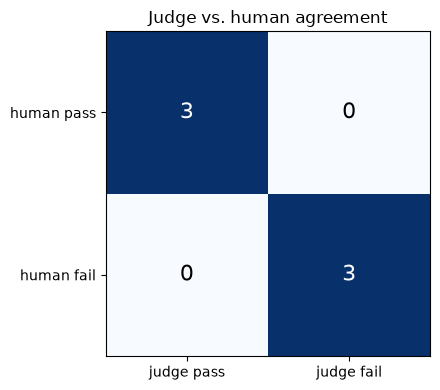

Off-diagonal cells are where the judge and a human disagree — the cases to inspect.


In [28]:
import matplotlib.pyplot as plt

# 2x2 confusion matrix: human (rows) vs judge (cols)
tp = sum(h and j for h, j in zip(human, judged))
fn = sum(h and not j for h, j in zip(human, judged))
fp = sum((not h) and j for h, j in zip(human, judged))
tn = sum((not h) and (not j) for h, j in zip(human, judged))
cm = [[tp, fn], [fp, tn]]

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["judge pass", "judge fail"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["human pass", "human fail"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i][j], ha="center", va="center", fontsize=16,
                color="white" if cm[i][j] > 1 else "black")
ax.set_title("Judge vs. human agreement")
plt.tight_layout(); plt.show()
print("Off-diagonal cells are where the judge and a human disagree — the cases to inspect.")

If accuracy and κ are high, the judge is a reasonable stand-in for human grading on this task. If not, the fix is almost always the **rubric** (make the bar concrete) or the **scale** (anchor the numbers) — the same levers we used against the biases in section 6. Validation is not a one-time step: re-run it whenever you change the judge model, the prompt, or the threshold.

## 9. (Optional) Run the *real* judge via Ollama

Everything above used a mock so it runs anywhere. The only change for a real judge is swapping `mock_judge_reply` for a call to an actual model — the parsing, clamping, fail-closed, and threshold logic are all unchanged.

This repo's `evals/judge.py` calls a local **Ollama** server (`gemma4:12b` judging `llama3.2` by default). The cell below runs the real judge on one open-ended case if Ollama is reachable, and skips cleanly otherwise. It grades a *good* and a *bad* answer so you can see the real model discriminate.

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # repo root is one level up from llm-eval/

case = {
    "prompt": "Explain what overfitting is in machine learning to a beginner.",
    "rubric": ("Correctly explains that a model learns the training data (including "
               "noise) too well and generalizes poorly to new/unseen data. Must be "
               "understandable to a beginner and factually correct."),
}
good_answer = ("Overfitting is when a model learns the training examples too well — "
               "including their random noise — so it scores high on that data but "
               "makes poor predictions on new, unseen data it wasn't trained on.")
bad_answer = "Overfitting is a way to compress a model so it runs faster on a phone."

try:
    from evals.judge import judge as real_judge
    JUDGE_MODEL = os.environ.get("JUDGE_MODEL", "gemma4:12b")
    HOST = os.environ.get("OLLAMA_HOST", "http://localhost:11434")
    for label, ans in [("good", good_answer), ("bad", bad_answer)]:
        j = real_judge(case["prompt"], ans, case["rubric"], model=JUDGE_MODEL, host=HOST)
        print(f"[{label}] score={j.score}/5  passed={j.passed}  reason={j.reason}")
except ImportError as e:
    print("Run from the repo so evals.judge is importable. Skipping.", e)
except Exception as e:
    print(f"Ollama not reachable / model missing — skipping live judge. ({type(e).__name__}: {e})")
    print("Start it with:  ollama serve   and   ollama pull gemma4:12b")

## Recap

| Component | Role | In this notebook / the repo |
|---|---|---|
| **Rubric + strict system prompt** | grade against defined criteria, not taste | `JUDGE_SYSTEM`, `JUDGE_TEMPLATE` |
| **Anchored 1–5 scale** | fight leniency/clustering | `JUDGE_TEMPLATE` |
| **Robust JSON extraction** | tolerate fences/prose | `extract_json` |
| **Fail-closed scoring + clamp** | a broken judge fails, never silently passes | `score_reply` |
| **Pass threshold** | trust the threshold, not the raw score | `score >= 4` |
| **Different judge model** | avoid self-enhancement bias | `gemma4:12b` judges `llama3.2` |
| **temperature 0 + fixed seed** | reproducible verdicts | `evals/client.py` |

**The five biases and their mitigations**
- **Verbosity** → system prompt forbids rewarding length + independent length graders.
- **Self-enhancement** → judge model ≠ model under test.
- **Position/ordering** → use absolute grading, not pairwise A/B.
- **Leniency/clustering** → anchored 1–5 scale, low temperature, pass threshold.
- **Non-determinism** → temperature 0, fixed seed, strict JSON contract.

**Key takeaways**
- Reach for a judge **last** — only for open-ended answers where no reference string or metric can pin down correctness.
- A judge is a **fallible model**: engineer the prompt against its known biases, and **fail closed** when you can't parse it.
- **Validate against human labels** (accuracy, Cohen's κ) before trusting a judge, and re-validate whenever you change the model, prompt, or threshold.
- The full stack in this repo: deterministic graders → BLEU/ROUGE (lexical) → BERTScore (semantic) → **LLM-judge** (open-ended). Each layer covers the blind spots of the ones below — no single evaluator is trusted alone.